# Task 1.1 — Sentiment Analysis with a Feedforward ANN

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
TF-IDF bag-of-words representation fed into a simple feedforward neural network.

**Pipeline overview**
```
Raw text  →  Preprocessing  →  TF-IDF vectors  →  ANN  →  {0, 1}
```

## Setup & Imports

In [1]:
import warnings
import pathlib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer

from utils import device_check, fit, evaluate
from plotting_tools import plot_confusion_matrix

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
LOG_WANDB   = True  # Set False to disable wandb logging
NUM_WORKERS = 8
PIN_MEMORY  = True
SEED = 1

# Make results reproducible
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## ANN Design

A feedforward network with **BatchNorm** and **Dropout** for regularization, with adjustable hidden layer count/size.

In [3]:
class SentimentANN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], activation: nn.Module = nn.ReLU(), dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                activation,
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 2))  # 2 output classes
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

---
## Initial Test — 1 K Amazon Reviews

### Load Pre-split Data

In [4]:
SPLITS_DIR = pathlib.Path('../data/splits')

train_df = pd.read_csv(SPLITS_DIR / '1k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '1k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '1k_test.csv')

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')
y_train = train_df['Class'].values.astype('int32')
y_val   = val_df['Class'].values.astype('int32')
y_test  = test_df['Class'].values.astype('int32')

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


### TF-IDF Vectorization

TF-IDF stands for Term Frequency–Inverse Document Frequency. The core idea is to represent each review as a fixed-length numeric vector where each position corresponds to a word (or word pair), and the value captures how distinctive that word is for that particular review.
The two components are:

1. TF (Term Frequency) — how often a word appears in this review. A review that says "great" three times scores higher on "great" than one that says it once.
2. IDF (Inverse Document Frequency) — a penalty for words that appear in most reviews. A word like "phone" appears in almost every review, so it tells you very little about sentiment and gets down-weighted. A word like "worthless" appears rarely and is much more informative.

Multiply them together, and you get a score that's high for words that are frequent in this review but rare across the dataset — exactly the words that carry signal.

The vectorizer is **fit only on the training set** to avoid data leakage, then used
to transform all three splits.

In [5]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams: consider single words like "good" AND pairs like "not good"
    max_features=50_000,  # cap vocabulary size
    max_df=0.5,           # drop words appearing in >50% of reviews
    use_idf=True,         # apply the IDF weighting
    norm='l2',            # normalize each row vector to unit length
)

X_train_t = torch.from_numpy(np.array(vectorizer.fit_transform(X_train).todense())).float()
X_val_t   = torch.from_numpy(np.array(vectorizer.transform(X_val).todense())).float()
X_test_t  = torch.from_numpy(np.array(vectorizer.transform(X_test).todense())).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = X_train_t.shape[1]
print(f'Vocabulary size (TF-IDF features): {INPUT_DIM}')

Vocabulary size (TF-IDF features): 4671


### DataLoaders

In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture

A three-layer feedforward network with **BatchNorm** and **Dropout** for regularization.

```
Input (vocab_size)  →  FC(256) → BN → ReLU → Dropout
                    →  FC(64)  → BN → ReLU → Dropout
                    →  FC(2)   →  logits
```

In [7]:
HIDDEN_DIMS = [256, 64]
DROPOUT = 0.5

model = SentimentANN(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')


Trainable parameters: 1,213,250


### Training

In [8]:
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="TFIDF ANN 1K",
    tags=["Task 1.1", "TFIDF", "1K"],
    config={
        "dataset": "Amazon 1K",
        "optimizer": optimizer,
        "hidden_dims": HIDDEN_DIMS,
        "weight_decay": WEIGHT_DECAY,
        "lr": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
    },
)

history = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch  1/50 | train loss 0.7604, train acc 53.09% | val loss 0.6931, val acc 51.11%
Epoch  2/50 | train loss 0.6947, train acc 57.90% | val loss 0.6924, val acc 50.00%
Epoch  3/50 | train loss 0.6488, train acc 63.58% | val loss 0.6908, val acc 50.00%
Epoch  4/50 | train loss 0.5827, train acc 70.37% | val loss 0.6823, val acc 52.22%
Epoch  5/50 | train loss 0.5310, train acc 74.69% | val loss 0.6659, val acc 64.44%
Epoch  6/50 | train loss 0.4727, train acc 78.02% | val loss 0.6346, val acc 72.22%
Epoch  7/50 | train loss 0.4318, train acc 82.22% | val loss 0.6028, val acc 75.56%
Epoch  8/50 | train loss 0.3939, train acc 85.68% | val loss 0.5772, val acc 74.44%
Epoch  9/50 | train loss 0.3449, train acc 88.15% | val loss 0.5623, val acc 73.33%
Epoch 10/50 | train loss 0.3000, train acc 93.70% | val loss 0.5496, val acc 75.56%
Epoch 11/50 | train loss 0.2819, train acc 94.44% | val loss 0.5400, val acc 75.56%
Epoch 12/50 | train loss 0.2660, train acc 95.31% | val loss 0.5310, val acc

Training Accuracy,▁▂▃▄▄▅▆▇▇▇▇█████████████████████████████
Training Loss,█▇▇▆▆▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▁▁▅▇▇██▇███▇▇▇▇▇▇█▇▇████▇▇█▇██▇█▇█▇████
Validation Loss,████▇▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▂▂▂▁▂▁▁▂▂
Training Accuracy,99.75309
Training Loss,0.03997
Validation Accuracy,75.55556
Validation Loss,0.50999



Restored best weights (val loss 0.4844)


### Evaluation on the Test Set

In [9]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF 1K Samples')

[ANN TF-IDF 1K Samples] Test loss: 0.4770 | Test acc: 75.00%


(0.4770349478721619, 75.0)

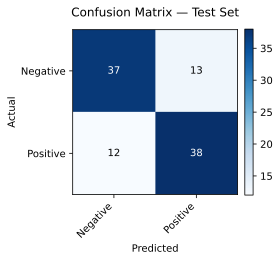

In [10]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='Confusion Matrix — Test Set',
)

---
## Scaling Up — 25 K Amazon Reviews

We now repeat the **exact same pipeline** on the larger `amazon_cells_labelled.txt` dataset (same tab-separated format, same binary labels).  The vectoriser and model are retrained **from scratch** on this corpus so the vocabulary properly reflects the larger training distribution.

### Load Pre-split Data

In [11]:
train_df = pd.read_csv(SPLITS_DIR / '25k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '25k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '25k_test.csv')

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')
y_train = train_df['Class'].values.astype('int32')
y_val   = val_df['Class'].values.astype('int32')
y_test  = test_df['Class'].values.astype('int32')

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 20,250  |  Val: 2,250  |  Test: 2,500


### TF-IDF Vectorisation

In [12]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams: consider single words like "good" AND pairs like "not good"
    max_features=100_000, # cap vocabulary size
    max_df=0.5,           # drop words appearing in >50% of reviews
    use_idf=True,         # apply the IDF weighting
    norm='l2',            # normalize each row vector to unit length
)

vectorizer.fit(X_train)

X_train_t = torch.from_numpy(np.array(vectorizer.fit_transform(X_train).todense())).float()
X_val_t   = torch.from_numpy(np.array(vectorizer.transform(X_val).todense())).float()
X_test_t  = torch.from_numpy(np.array(vectorizer.transform(X_test).todense())).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = X_train_t.shape[1]
print(f'Vocabulary size (TF-IDF features): {INPUT_DIM}')

Vocabulary size (TF-IDF features): 100000


### DataLoaders

In [13]:
BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

In [14]:
HIDDEN_DIMS = [256, 64]
ACTIVATION = nn.ReLU()
DROPOUT = 0.5
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3

model = SentimentANN(
    input_dim=INPUT_DIM, 
    hidden_dims=HIDDEN_DIMS, 
    dropout=DROPOUT, 
    activation=ACTIVATION
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="TFIDF ANN 25K",
    tags=["Task 1.1", "TFIDF", "25K"],
    config={
        "dataset": "Amazon 25K",
        "activation": ACTIVATION,
        "optimizer": optimizer,
        "hidden_dims": HIDDEN_DIMS,
        "weight_decay": WEIGHT_DECAY,
        "lr": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
    },
)

history = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

Epoch  1/50 | train loss 0.5399, train acc 71.81% | val loss 0.5142, val acc 86.67%
Epoch  2/50 | train loss 0.2859, train acc 92.21% | val loss 0.3178, val acc 87.91%
Epoch  3/50 | train loss 0.1655, train acc 97.73% | val loss 0.3111, val acc 87.51%
Epoch  4/50 | train loss 0.1024, train acc 99.42% | val loss 0.3038, val acc 87.78%
Epoch  5/50 | train loss 0.0717, train acc 99.81% | val loss 0.3021, val acc 87.56%
Epoch  6/50 | train loss 0.0538, train acc 99.93% | val loss 0.3041, val acc 87.51%
Epoch  7/50 | train loss 0.0415, train acc 99.99% | val loss 0.3048, val acc 87.82%
Epoch  8/50 | train loss 0.0326, train acc 99.99% | val loss 0.3107, val acc 87.82%
Epoch  9/50 | train loss 0.0269, train acc 99.98% | val loss 0.3136, val acc 88.00%
Epoch 10/50 | train loss 0.0225, train acc 100.00% | val loss 0.3229, val acc 88.13%
Epoch 11/50 | train loss 0.0193, train acc 99.99% | val loss 0.3263, val acc 87.51%
Epoch 12/50 | train loss 0.0166, train acc 100.00% | val loss 0.3289, val a

Training Accuracy,▁▆▇█████████████████████████████████████
Training Loss,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▄▇▇▇▇██▆▆▇▇▇▆▆▇▇▇▆▅▅▅▅▆▆▆▅▅▅▃▄▅▄▄▅▄▄▃▃▁▂
Validation Loss,▇▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇█
Training Accuracy,99.50123
Training Loss,0.01821
Validation Accuracy,85.91111
Validation Loss,0.56304



Restored best weights (val loss 0.3021)


### Test-Set Evaluation & Confusion Matrix

In [15]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF — 25K Samples')

[ANN TF-IDF — 25K Samples] Test loss: 0.3149 | Test acc: 86.92%


(0.3148842764854431, 86.92)

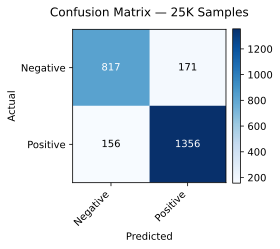

In [16]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='Confusion Matrix — 25K Samples',
)